## Basic trip over a single edge
In this notebook, we set up a basic simulation where one vessel moves over a 1D network path. The example aims to provide a basic understanding of some key OpenTNSim core functions and shows what a basic OpenTNSim model run looks like. 

#### 0. Import libraries

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from pyproj import Geod
from shapely.geometry import Point

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime, time
import simpy
import opentnsim

# package(s) needed for inspecting the output
import pandas as pd

# package(s) needed for plotting
import plotly.express as px

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.7


#### 1. Define object classes

In [2]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (
        opentnsim.core.Identifiable, # allows to give the object a name and a random ID,
        opentnsim.core.Movable,      # allows the object to move, with a fixed speed, while logging this activity
    ), 
    {}
)

#### 2. Create graph
Next we create a network (a graph) along which the vessel can move. For this case we create a single edge of 100 km exactly.

In [3]:
# initialize geodetic calculator with WGS84 ellipsoid
geod = Geod(ellps="WGS84")

In [4]:
# starting point (longitude, latitude)
lon0, lat0 = 0, 0

# compute the other point 100 km East from Point 0
lon1, lat1, _ = geod.fwd(lon0, lat0, 90, 100000) # East from Point 0

# define nodes with their geographic coordinates
coords = {
    "0": (lon0, lat0),
    "1": (lon1, lat1),
}

In [5]:
# create list of edges
edges = [("0", "1"), ("1", "0")] # bi-directional edge

In [6]:
# create a directed graph
FG = nx.DiGraph()

# add nodes
for name, coord in coords.items():
    FG.add_node(name, geometry=Point(coord[0], coord[1]))

# add edges
for edge in edges:
    FG.add_edge(edge[0], edge[1], weight=1)

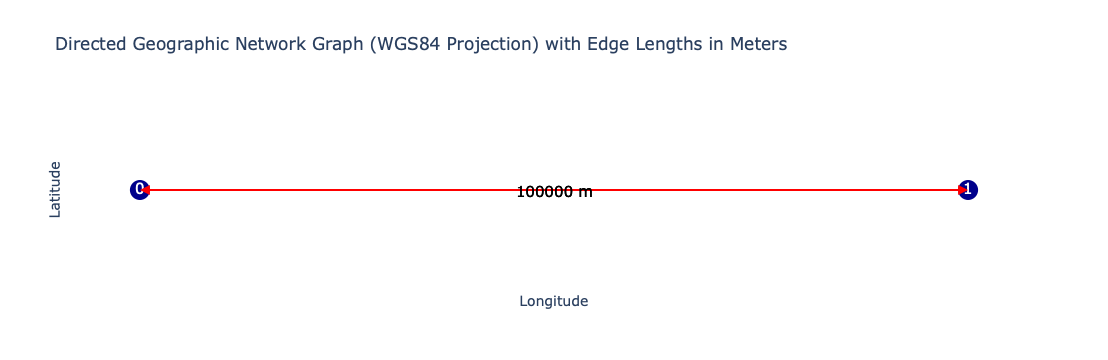

In [7]:
opentnsim.graph.plot_graph(FG)

#### 3. Run simulation

In [8]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel. 
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [9]:
# start simpy environment
simulation_start = datetime.datetime(2024, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

GeneralDepth = 10 # m
Current = 1 # m/s

# add graph to environment
FG.edges['0', '1']['Info'] = {'GeneralDepth': GeneralDepth, 'Current': -Current} # from '0' to '1' you sail against the current
FG.edges['1', '0']['Info'] = {'GeneralDepth': GeneralDepth, 'Current':  Current} # from '1' to '0' you sail with the current
env.graph = FG

# create vessel from a dict 
path = nx.dijkstra_path(env.graph, "0", "1")
path.append('0')

data_vessel = {
    "env": env,                                       # needed for simpy simulation
    "name": "Vessel",                                 # required by Identifiable
    "geometry": env.graph.nodes[path[0]]['geometry'], # required by Locatable
    "route": path,                                    # required by Routeable
    "v": 3,                                           # required by Movable, 1 m/s to check if the distance is covered in the expected time
}  # 

# create an instance of the Vessel class using the input dict data_vessel
vessel = Vessel(**data_vessel)

# start the simulation
env.process(mission(env, vessel))
env.run()

#### 4. Inspect output
We can now inspect  the simulation output by inspecting the _vessel.logbook_. Note that the _Log_ mix-in was included when we added _Movable_. The _vessel.logbook_ keeps track of the moving activities of the vessel. For each discrete event OpenTNSim logs an event message, the start/stop time and the location. The _vessel.logbook_ is of type dict. For convenient inspection it can be loaded into a Pandas dataframe. 

In [10]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel.logbook)

print("'{}' logbook data:".format(vessel.name))  
print('')

display(df)

trip_distance = opentnsim.graph.calculate_distance_along_path(FG, vessel.route)
trip_duration = datetime.timedelta.total_seconds(vessel.logbook[-1]['Timestamp'] - vessel.logbook[0]['Timestamp'])

print("'{}' travelled a distance of {:.1f} meters".format(vessel.name, trip_distance))
print("'{}' took {:.1f} seconds to arrive at its destination".format(vessel.name, trip_duration))  
print("'{}' travelled at an average speed of {:.1f} meters per second".format(vessel.name, trip_distance/trip_duration))
print('')
print('')

'Vessel' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 0 to node 1 start,2024-01-01 00:00:00,0,POINT (0 0)
1,Sailing from node 0 to node 1 stop,2024-01-01 13:53:20,0,POINT (0.8983152841195217 0)
2,Sailing from node 1 to node 0 start,2024-01-01 13:53:20,0,POINT (0.8983152841195217 0)
3,Sailing from node 1 to node 0 stop,2024-01-01 20:50:00,0,POINT (0 0)


'Vessel' travelled a distance of 200000.0 meters
'Vessel' took 75000.0 seconds to arrive at its destination
'Vessel' travelled at an average speed of 2.7 meters per second




The inspection of the logbook data shows that Vessel moved from its origin (*Node 0*) to its destination (*Node 1*). The print statements show that the length of the route from *Node 0* to *Node 1* is exactly 100 km. At a given speed of 1 m/s the trip duration should be exactly 100000 seconds, as is indeed shown to be the case.

In [11]:
# TODO: naar de package verplaatsen - mogelijk in een log module plaatsen
def logbook_to_eventtable(objs):
    """Method to transform object logbook, that contains a list of activity start/stop logs, into a 'minimum event table'. 
    
    This method implements the basic 'event table' concept as proposed by Van der Werff:

    Van der Werff, S.E., F. Baart and M. van Koningsveld (2025). “Merging Multiple System Perspectives: The Key to 
    Effective Inland Shipping Emission-Reduction Policy Design.” Journal of Marine Science and engineering 13(4), 716. 
    https://doi.org/10.3390/jmse13040716 

    Van der Werff, S.E., S. Eppenga, A. van der Hout, F. Baart and M. van Koningsveld (2025). “Multi-perspective 
    nautical safety risk assessment of allisions with offshore wind parks.” Applied Ocean Research 158(2025),104564. 
    https://doi.org/10.1016/j.apor.2025.104564 

    For waterborne traffic travelling over a water transport network, a unique event is defined by a combination of: 
     - a unique vessel, 
     - that travels a specific section of the waterway, 
     - at a specific time.

    Parameters
    ----------
    objs: list
        list of OpenTNSim simulation objects that have log information

    Returns
    -------
    df: pandas.DataFrame
        dataframe that contains all events encapsulated in the obj.logbook attributes in the input list of objs
    """
    
    events = []
    for obj in objs:
        df = pd.DataFrame.from_dict(obj.logbook)
        for i in range(0, len(df), 2):
            activity = df.iloc[i]['Message'].replace(' start', '')
            
            start_time = df.iloc[i]['Timestamp']
            stop_time = df.iloc[i+1]['Timestamp']
            start_location = df.iloc[i]['Geometry']
            stop_location = df.iloc[i+1]['Geometry']
            
            duration_seconds = (stop_time - start_time).total_seconds()
            distance_meters = opentnsim.graph.calculate_distance(start_location, stop_location)
            
            events.append({
                'object id': obj.id,
                'object name': obj.name,
                'activity name': activity,
                'start location': start_location,
                'stop location': stop_location,
                'start time': start_time,
                'stop time': stop_time,
                'distance (m)': distance_meters,
                'duration (s)': duration_seconds,
            })
        
    # Final DataFrame
    df = pd.DataFrame(events)
    
    return df

In [12]:
df_eventtable = logbook_to_eventtable([vessel])
df_eventtable

,object id,object name,activity name,start location,stop location,start time,stop time,distance (m),duration (s)
0,87c659fe-c603-4468-8fe3-1e96b2c7ae6c,Vessel,Sailing from node 0 to node 1,POINT (0 0),POINT (0.8983152841195217 0),2024-01-01 00:00:00,2024-01-01 13:53:20,100000.0,50000.0
1,87c659fe-c603-4468-8fe3-1e96b2c7ae6c,Vessel,Sailing from node 1 to node 0,POINT (0.8983152841195217 0),POINT (0 0),2024-01-01 13:53:20,2024-01-01 20:50:00,100000.0,25000.0


In [13]:
def generate_vessel_gantt_chart(df_eventtable: pd.DataFrame):
    """Method to generate a Gantt chart from a vessel activity log DataFrame.

    This method visualizes the activity timeline of vessels by combining vessel names and activity types into a single label,
    and plotting them using Plotly Express's timeline chart. 

    Parameters
    ----------
    df_eventtable : pandas.DataFrame
        DataFrame containing columns 'object name', 'activity name', 'start time', and 'stop time' representing vessel activity logs.

    Returns
    -------
    fig : plotly.graph_objects.Figure
        A Plotly figure object representing the Gantt chart of vessel activities.
    """
    
    # Add vessel name to activity label
    df_eventtable['activity label'] = df_eventtable['object name'] + ' - ' + df_eventtable['activity name']

    # Create the Gantt chart
    fig = px.timeline(
        df_eventtable,
        x_start="start time",
        x_end="stop time",
        y="activity label",
        color="object name",
        title="Gantt chart of logged events"
    )

    # Reverse the Y-axis to match Gantt chart style
    fig.update_yaxes(autorange="reversed")

    # Customize layout
    fig.update_layout(
        xaxis_title="Time",
        yaxis_title="Activity (with Vessel)",
        legend_title="Vessel",
        margin=dict(l=20, r=20, t=40, b=20)
    )

    return fig

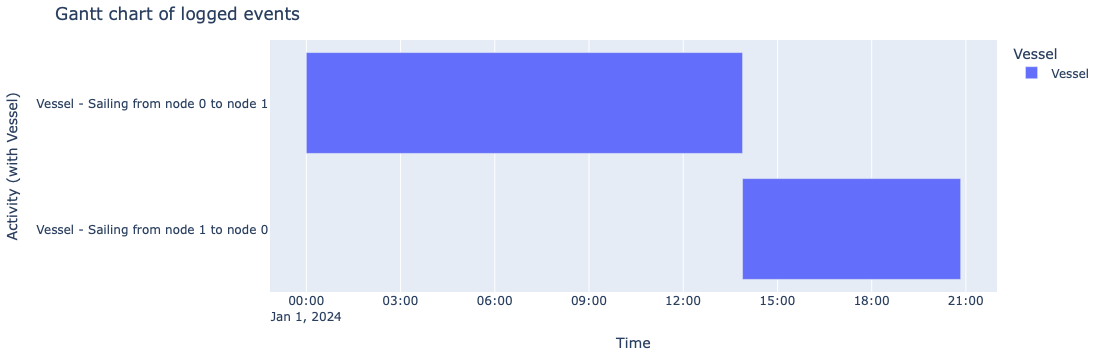

In [14]:
generate_vessel_gantt_chart(df_eventtable)